### GTSRB Data Preprocessing and Dataset Preparation

This notebook prepares the GTSRB dataset for machine learning experiments.

The main objectives are to:

- create stratified training and validation splits;
- preserve the official test set;
- define image preprocessing and data augmentation;
- create a custom PyTorch Dataset;
- create DataLoader objects;
- verify image and label shapes;
- inspect preprocessed images;
- save the dataset splits for reproducible experiments.

In [1]:
from pathlib import Path
import sys
import random

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

#### 1. Reproducibility Settings

Random seeds are fixed so that the dataset split and random operations can be reproduced.

In [2]:
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_SEED)
    torch.cuda.manual_seed_all(RANDOM_SEED)

print("Random seed:", RANDOM_SEED)

Random seed: 42


#### 2. Define Project Paths

In [3]:
PROJECT_ROOT = Path("..")

DATA_DIR = PROJECT_ROOT / "data" / "raw" / "archive"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"

TRAIN_CSV_PATH = DATA_DIR / "Train.csv"
TEST_CSV_PATH = DATA_DIR / "Test.csv"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Data directory:", DATA_DIR.resolve())
print("Processed directory:", PROCESSED_DIR.resolve())

Data directory: /Users/liuyuhan/Desktop/traffic_recognition/data/raw/archive
Processed directory: /Users/liuyuhan/Desktop/traffic_recognition/data/processed


In [4]:
train_csv = pd.read_csv(TRAIN_CSV_PATH)
test_csv = pd.read_csv(TEST_CSV_PATH)

print("Original training data shape:", train_csv.shape)
print("Official test data shape:", test_csv.shape)

display(train_csv.head())

Original training data shape: (39209, 8)
Official test data shape: (12630, 8)


,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png


#### 3. Create Stratified Training and Validation Splits

The original training set is divided into:

- 80% training data;
- 20% validation data.

Stratified splitting preserves the proportion of each class in both subsets.

The official test set remains separate and is not used during model training or hyperparameter selection.

In [5]:
train_df, val_df = train_test_split(
    train_csv,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=train_csv["ClassId"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_csv.reset_index(drop=True)

print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Test samples:", len(test_df))

Training samples: 31367
Validation samples: 7842
Test samples: 12630


In [6]:
print("Training classes:", train_df["ClassId"].nunique())
print("Validation classes:", val_df["ClassId"].nunique())
print("Test classes:", test_df["ClassId"].nunique())

print("\nTraining class ID range:")
print(train_df["ClassId"].min(), "to", train_df["ClassId"].max())

print("\nValidation class ID range:")
print(val_df["ClassId"].min(), "to", val_df["ClassId"].max())

print("\nTest class ID range:")
print(test_df["ClassId"].min(), "to", test_df["ClassId"].max())

Training classes: 43
Validation classes: 43
Test classes: 43

Training class ID range:
0 to 42

Validation class ID range:
0 to 42

Test class ID range:
0 to 42


In [7]:
train_paths = set(train_df["Path"])
val_paths = set(val_df["Path"])

overlapping_paths = train_paths.intersection(val_paths)

print("Number of overlapping paths:", len(overlapping_paths))

Number of overlapping paths: 0


#### 4. Compare Class Distributions

The following comparison checks whether stratification preserved the original class proportions.

In [8]:
original_proportions = (train_csv["ClassId"].value_counts(normalize=True).sort_index())

train_proportions = (train_df["ClassId"].value_counts(normalize=True).sort_index())

val_proportions = (val_df["ClassId"].value_counts(normalize=True).sort_index())

distribution_comparison = pd.DataFrame({
    "Original": original_proportions,
    "Training": train_proportions,
    "Validation": val_proportions
})

display(distribution_comparison.head(10))

,Original,Training,Validation
0,0.005356,0.005356,0.005356
1,0.056620,0.056620,0.056618
2,0.057385,0.057385,0.057383
3,0.035961,0.035961,0.035960
4,0.050499,0.050499,0.050497
5,0.047438,0.047438,0.047437
6,0.010712,0.010712,0.010712
7,0.036726,0.036726,0.036725
8,0.035961,0.035961,0.035960
9,0.037491,0.037492,0.037490


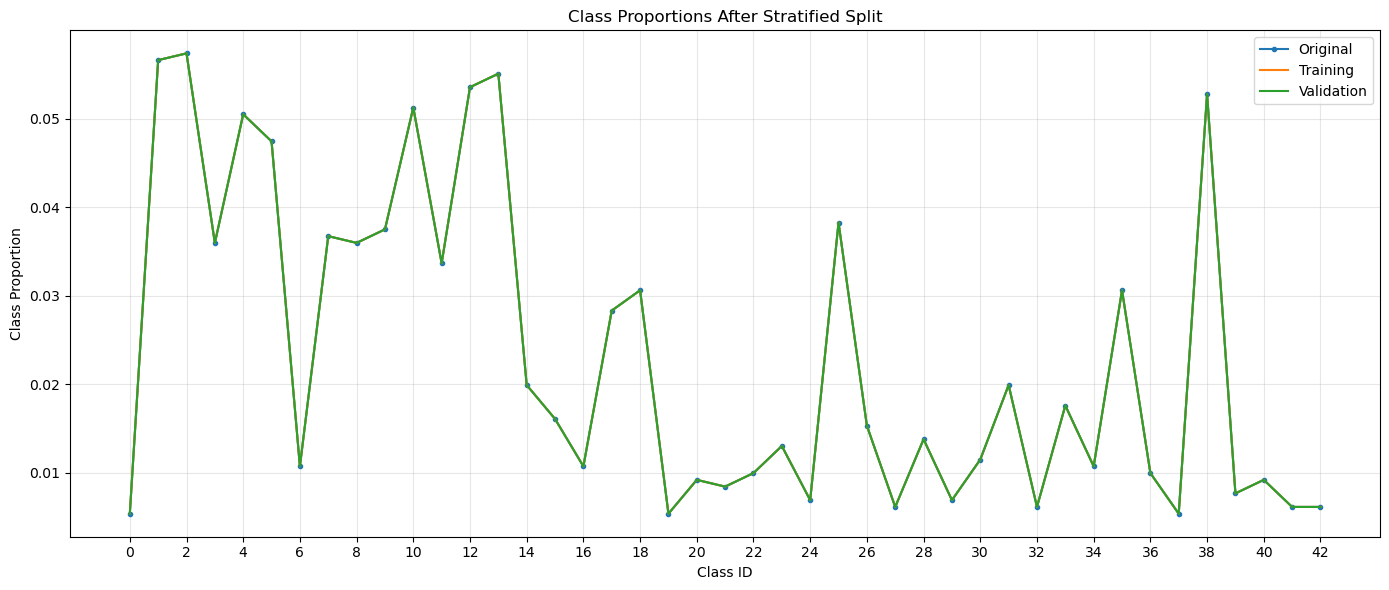

In [9]:
plt.figure(figsize=(14, 6))

plt.plot(distribution_comparison.index, distribution_comparison["Original"], marker="o", markersize=3, label="Original")

plt.plot(distribution_comparison.index, distribution_comparison["Training"], label="Training")

plt.plot(distribution_comparison.index, distribution_comparison["Validation"], label="Validation")

plt.xlabel("Class ID")
plt.ylabel("Class Proportion")
plt.title("Class Proportions After Stratified Split")
plt.xticks(range(0, 43, 2))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(FIGURES_DIR / "stratified_split_class_proportions.png", dpi=300, bbox_inches="tight")

plt.show()

In [10]:
train_difference = (distribution_comparison["Original"] - distribution_comparison["Training"]).abs().max()

val_difference = (distribution_comparison["Original"] - distribution_comparison["Validation"]).abs().max()

print("Maximum difference between original and training proportions:", round(train_difference, 6))

print("Maximum difference between original and validation proportions:", round(val_difference, 6))

Maximum difference between original and training proportions: 6e-06
Maximum difference between original and validation proportions: 2.5e-05


#### 5. Save Dataset Splits

Saving the splits ensures that all future experiments use exactly the same training, validation and test datasets.

In [11]:
TRAIN_SPLIT_PATH = PROCESSED_DIR / "train_split.csv"
VALIDATION_SPLIT_PATH = PROCESSED_DIR / "validation_split.csv"
TEST_SPLIT_PATH = PROCESSED_DIR / "test_split.csv"

train_df.to_csv(TRAIN_SPLIT_PATH, index=False)

val_df.to_csv(VALIDATION_SPLIT_PATH, index=False)

test_df.to_csv(TEST_SPLIT_PATH, index=False)

print("Training split saved to:", TRAIN_SPLIT_PATH)
print("Validation split saved to:", VALIDATION_SPLIT_PATH)
print("Test split saved to:", TEST_SPLIT_PATH)

Training split saved to: ../data/processed/train_split.csv
Validation split saved to: ../data/processed/validation_split.csv
Test split saved to: ../data/processed/test_split.csv


In [12]:
saved_train_df = pd.read_csv(TRAIN_SPLIT_PATH)
saved_val_df = pd.read_csv(VALIDATION_SPLIT_PATH)
saved_test_df = pd.read_csv(TEST_SPLIT_PATH)

print("Saved training shape:", saved_train_df.shape)
print("Saved validation shape:", saved_val_df.shape)
print("Saved test shape:", saved_test_df.shape)

Saved training shape: (31367, 8)
Saved validation shape: (7842, 8)
Saved test shape: (12630, 8)


#### 6. Define Image Transformations

For the baseline CNN, images are resized to 32 × 32 pixels.

Training images receive mild augmentation:

- small random rotation;
- brightness adjustment;
- contrast adjustment;
- saturation adjustment.

Horizontal and vertical flipping are not used because these transformations may change the meaning of directional traffic signs.

Validation and test images are processed deterministically without random augmentation.

In [13]:
IMAGE_SIZE = 32
BATCH_SIZE = 64
NUMBER_OF_CLASSES = 43

print("Image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)
print("Number of classes:", NUMBER_OF_CLASSES)

Image size: 32
Batch size: 64
Number of classes: 43


In [14]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.RandomRotation(degrees=10),

    transforms.ColorJitter(brightness=0.20, contrast=0.20, saturation=0.10),

    transforms.ToTensor(),

    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])


evaluation_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

print(train_transform)
print()
print(evaluation_transform)

Compose(
    Resize(size=(32, 32), interpolation=bilinear, max_size=None, antialias=True)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.9, 1.1), hue=None)
    ToTensor()
    Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
)

Compose(
    Resize(size=(32, 32), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
)


#### 7. Custom PyTorch Dataset

The custom dataset reads image paths and class labels from the CSV files.

In [15]:
class TrafficSignDataset(Dataset):
    def __init__(self, dataframe, root_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.root_dir = Path(root_dir)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        if index < 0 or index >= len(self.dataframe):
            raise IndexError(
                f"Index {index} is outside dataset range."
            )

        row = self.dataframe.iloc[index]

        image_path = self.root_dir / row["Path"]

        if not image_path.exists():
            raise FileNotFoundError(f"Image file not found: {image_path}")

        with Image.open(image_path) as image:
            image = image.convert("RGB")

        label = int(row["ClassId"])

        if self.transform is not None:
            image = self.transform(image)

        return image, label

#### 8. Create Training, Validation and Test Datasets

In [16]:
train_dataset = TrafficSignDataset(
    dataframe=train_df,
    root_dir=DATA_DIR,
    transform=train_transform
)

val_dataset = TrafficSignDataset(
    dataframe=val_df,
    root_dir=DATA_DIR,
    transform=evaluation_transform
)

test_dataset = TrafficSignDataset(
    dataframe=test_df,
    root_dir=DATA_DIR,
    transform=evaluation_transform
)

print("Training dataset size:", len(train_dataset))
print("Validation dataset size:", len(val_dataset))
print("Test dataset size:", len(test_dataset))

Training dataset size: 31367
Validation dataset size: 7842
Test dataset size: 12630


In [17]:
sample_image, sample_label = train_dataset[0]

print("Sample image shape:", sample_image.shape)
print("Sample image data type:", sample_image.dtype)
print("Sample label:", sample_label)
print("Sample label type:", type(sample_label))

Sample image shape: torch.Size([3, 32, 32])
Sample image data type: torch.float32
Sample label: 12
Sample label type: <class 'int'>


In [18]:
print("Minimum pixel value:", sample_image.min().item())
print("Maximum pixel value:", sample_image.max().item())
print("Mean pixel value:", sample_image.mean().item())

Minimum pixel value: -1.0
Maximum pixel value: -0.545098066329956
Mean pixel value: -0.8156352043151855


#### 9. Create DataLoaders

The training loader shuffles the data before each epoch.

The validation and test loaders do not shuffle because their ordering is not important for training.

In [19]:
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("Number of training batches:", len(train_loader))
print("Number of validation batches:", len(val_loader))
print("Number of test batches:", len(test_loader))

Number of training batches: 491
Number of validation batches: 123
Number of test batches: 198


#### 10. DataLoader Sanity Check

A batch is inspected to confirm that images and labels have the expected shapes and data types.

In [20]:
batch_images, batch_labels = next(iter(train_loader))

print("Image batch shape:", batch_images.shape)
print("Label batch shape:", batch_labels.shape)

print("Image data type:", batch_images.dtype)
print("Label data type:", batch_labels.dtype)

print("Minimum label in batch:", batch_labels.min().item())
print("Maximum label in batch:", batch_labels.max().item())

Image batch shape: torch.Size([64, 3, 32, 32])
Label batch shape: torch.Size([64])
Image data type: torch.float32
Label data type: torch.int64
Minimum label in batch: 1
Maximum label in batch: 38


In [21]:
assert batch_images.ndim == 4
assert batch_images.shape[1] == 3
assert batch_images.shape[2] == IMAGE_SIZE
assert batch_images.shape[3] == IMAGE_SIZE

assert batch_labels.ndim == 1
assert batch_images.shape[0] == batch_labels.shape[0]

assert batch_labels.min().item() >= 0
assert batch_labels.max().item() < NUMBER_OF_CLASSES

print("All batch shape and label checks passed.")

All batch shape and label checks passed.


#### 11. Visualise Preprocessed Training Images

The normalisation is reversed before displaying the images.

In [22]:
def denormalise_image(image_tensor):
    image = image_tensor.permute(1, 2, 0).numpy()

    image = image * 0.5 + 0.5
    image = np.clip(image, 0, 1)

    return image

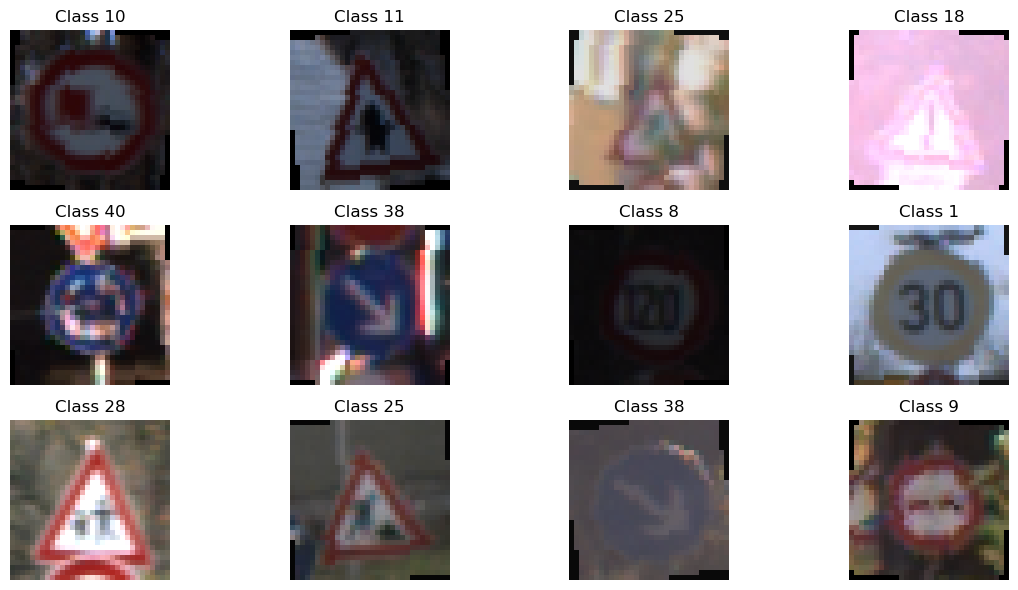

In [23]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 6))

number_of_images_to_show = 12

for index in range(number_of_images_to_show):
    image = denormalise_image(images[index])

    plt.subplot(3, 4, index + 1)
    plt.imshow(image)
    plt.title(f"Class {labels[index].item()}")
    plt.axis("off")

plt.tight_layout()

plt.savefig(FIGURES_DIR / "preprocessed_training_images.png", dpi=300, bbox_inches="tight")

plt.show()

#### 12. Compare Original and Augmented Images

The same original image is transformed several times to demonstrate the random augmentation.

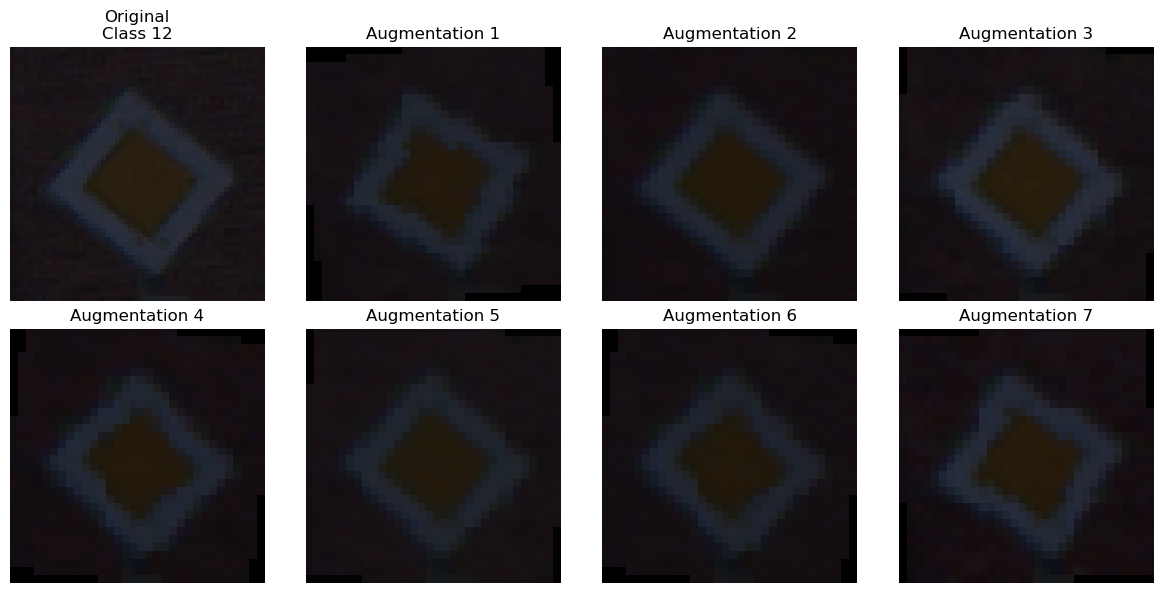

In [24]:
sample_row = train_df.iloc[0]
sample_path = DATA_DIR / sample_row["Path"]

with Image.open(sample_path) as original_image:
    original_image = original_image.convert("RGB")

    plt.figure(figsize=(12, 6))

    plt.subplot(2, 4, 1)
    plt.imshow(original_image)
    plt.title(f"Original\nClass {sample_row['ClassId']}")
    plt.axis("off")

    for index in range(1, 8):
        augmented_tensor = train_transform(original_image)
        augmented_image = denormalise_image(augmented_tensor)

        plt.subplot(2, 4, index + 1)
        plt.imshow(augmented_image)
        plt.title(f"Augmentation {index}")
        plt.axis("off")

plt.tight_layout()

plt.savefig(FIGURES_DIR / "augmentation_examples.png", dpi=300, bbox_inches="tight")

plt.show()

#### 13. Check All Dataset Samples

This check confirms that all images can be loaded and transformed successfully.

In [26]:
def validate_dataset(dataset, dataset_name):
    invalid_samples = []

    for index in range(len(dataset)):
        try:
            image, label = dataset[index]

            if image.shape != (3, IMAGE_SIZE, IMAGE_SIZE):
                invalid_samples.append(
                    {
                        "Index": index,
                        "Reason": f"Unexpected shape: {image.shape}"
                    }
                )

            if not 0 <= label < NUMBER_OF_CLASSES:
                invalid_samples.append(
                    {
                        "Index": index,
                        "Reason": f"Invalid label: {label}"
                    }
                )

        except Exception as error:
            invalid_samples.append(
                {
                    "Index": index,
                    "Reason": str(error)
                }
            )

    print(
        f"{dataset_name}: "
        f"{len(invalid_samples)} invalid samples"
    )

    return invalid_samples

In [27]:
invalid_train_samples = validate_dataset(train_dataset, "Training dataset")

invalid_val_samples = validate_dataset(val_dataset, "Validation dataset")

invalid_test_samples = validate_dataset(test_dataset, "Test dataset")

Training dataset: 0 invalid samples
Validation dataset: 0 invalid samples
Test dataset: 0 invalid samples


In [28]:
validation_summary = pd.DataFrame({
    "Dataset": [
        "Training",
        "Validation",
        "Test"
    ],
    "NumberOfSamples": [
        len(train_dataset),
        len(val_dataset),
        len(test_dataset)
    ],
    "InvalidSamples": [
        len(invalid_train_samples),
        len(invalid_val_samples),
        len(invalid_test_samples)
    ]
})

display(validation_summary)

,Dataset,NumberOfSamples,InvalidSamples
0,Training,31367,0
1,Validation,7842,0
2,Test,12630,0


#### 14. Dataset Preparation Summary

- The original GTSRB training set was divided into training and validation subsets using an 80:20 stratified split.
- Stratification preserved the class distribution in both subsets.
- The official test set was kept separate and was not used during training or validation.
- Dataset splits were saved as CSV files to support reproducible experiments.
- Images were resized to 32 × 32 pixels for the baseline CNN.
- All images were converted to RGB format.
- Pixel values were converted to tensors and normalised.
- Mild random rotation and colour adjustments were applied only to the training set.
- Horizontal and vertical flipping were not used because these transformations could alter the semantic meaning of directional traffic signs.
- Validation and test images were processed without random augmentation.
- The PyTorch Dataset and DataLoader objects successfully produced image batches with shape `[batch size, 3, 32, 32]`.
- Labels were stored as integer class IDs between 0 and 42.

In [30]:
preprocessing_summary = pd.DataFrame({
    "Setting": [
        "Random seed",
        "Training samples",
        "Validation samples",
        "Test samples",
        "Number of classes",
        "Image width",
        "Image height",
        "Number of channels",
        "Batch size",
        "Training augmentation",
        "Horizontal flipping",
        "Normalisation mean",
        "Normalisation standard deviation"
    ],
    "Value": [
        RANDOM_SEED,
        len(train_dataset),
        len(val_dataset),
        len(test_dataset),
        NUMBER_OF_CLASSES,
        IMAGE_SIZE,
        IMAGE_SIZE,
        3,
        BATCH_SIZE,
        "Random rotation and colour jitter",
        "Not used",
        "[0.5, 0.5, 0.5]",
        "[0.5, 0.5, 0.5]"
    ]
})

display(preprocessing_summary)

preprocessing_summary.to_csv(RESULTS_DIR / "preprocessing_summary.csv", index=False)

validation_summary.to_csv(RESULTS_DIR / "dataset_validation_summary.csv", index=False)

distribution_comparison.to_csv(RESULTS_DIR / "split_distribution_comparison.csv")

print("Preprocessing summary files saved successfully.")

,Setting,Value
0,Random seed,42
1,Training samples,31367
2,Validation samples,7842
3,Test samples,12630
4,Number of classes,43
5,Image width,32
6,Image height,32
7,Number of channels,3
8,Batch size,64
9,Training augmentation,Random rotation and colour jitter


Preprocessing summary files saved successfully.
